In [107]:
# 라이브러리 호출
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

In [108]:
df = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])
df.head()

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   
3               217           0.008                 11  ...           0   
4               217           0.008                 12  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   
3       0      0             0               0          0       0         0   
4       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  
3             0            0  
4             0            0  

[5 rows x 57 columns]

---
## 6 컬럼 구조 확인

#### Process 컬럼 (17개)
- 다이캐스팅 공정에서 설정한 조건(속도·압력·시간·형체력 등)을 모아둔 변수
1. id: 설비/레코드 식별자(ID)
2. Product_Type: 제품 유형을 1/2로 구분한 코드
3. Shot: 생산 순서(샷 번호)
4. Velocity_1: 금형에 용탕을 투입(사출)하는 속도(1단)
5. Velocity_2: 사출 속도 2단(중간 구간 속도)
6. Velocity_3: 사출 속도 3단(후반 구간 속도)
7. High_Velocity: 사출 과정에서의 최고 속도(피크)
8. Cylinder_Pressure: shot을 찍기 위한 실린더 압력이다.
9. Rapid_Rise_Time: 실린더 압력 상승 시간(압력이 급히 올라가는 데 걸린 시간)이다. 
10. Biscuit_Thickness: 주조 후 샷 슬리브에 남는 주조 비스켓(잔류 금속) 두께다. 
11. Clamping_Force: shot을 찍을 때 금형을 밀어주는 형체력(클램핑 힘)
12. Cycle_Time: 제품이 나오기까지 걸리는 총 사이클 시간
13. Pressure_Rise_Time: 압력이 목표치로 올라가는 데 걸린 시간
14. Casting_Pressure: shot을 찍을 때의 주조 압력
15. spray_Time: 스프레이 작업에 걸린 전체 시간
16. Spray_1_Time: 스프레이 1단 구간 시간
17. Spray_2_Time: 스프레이 2단 구간 시간

#### Sensor 컬럼(14)
- 설비/환경이 실제로 측정한 상태값(온도·압력·습도 등)을 모아둔 센서 변수
1. Melting_Furnace_Temp: 용해로(용탕) 온도
2. Air_Pressure: 공압(에어) 라인 압력 (스프레이/블로우/공압 구동 안정성 신호로 해석 가능)
3. Air_Pressure_Min: 해당 구간에서 기록된 에어 압력 최소값
4. Air_Pressure_Max: 해당 구간에서 기록된 에어 압력 최대값
5. Coolant_Temp: 냉각수 온도
6. Coolant_Temp_Min: 해당 구간 냉각수 온도 최소값
7. Coolant_Temp_Max: 해당 구간 냉각수 온도 최대값
8. Coolant_Pressure: 냉각수 압력
9. Factory_Temp: 공장(주변 환경) 온도
10. Factory_Temp_Min: 공장 온도 최소값
11. Factory_Temp_Max: 공장 온도 최대값
12. Factory_Humidity: 공장(주변 환경) 습도
13. Factory_Humidity_Min: 공장 습도 최소값
14. Factory_Humidity_Max: 공장 습도 최대값 

#### Defects 컬럼 (26)
- 각 샷의 검사 결과로 확인된 불량 라벨
- _1/_2는 캐비티 1/2(금형의 두 캐비티) 를 뜻한다.
- 값은 보통 0=정상, 1=불량 발생
- 2 이상이 존재함 (이는 발생 있음 으로 취급해도 무관하다 판단)
1. Short_Shot_1: 미성형(충전 부족) 불량
2. Short_Shot_2: 미성형(충전 부족) 불량
3. Bubble_1: 기포 불량
4. Bubble_2: 기포 불량 
5. Exfoliation_1: 박리(층 분리/벗겨짐) 불량 
6. Exfoliation_2: 박리(층 분리/벗겨짐) 불량 
7. Blow_Hole_1: 블로홀/기공 불량 
8. Blow_Hole_2: 블로홀/기공 불량 
9. Stain_1: 얼룩 불량 
10. Stain_2: 얼룩 불량 
11. Dent_1: 찍힘/눌림 불량 
12. Dent_2: 찍힘/눌림 불량 
13. Scratch_1: 스크래치 불량 
14. Scratch_2: 스크래치 불량 
15. Buring_Mark_1: 번마크/그을림 불량 
16. Buring_Mark_2: 번마크/그을림 불량 
17. Deformation_1: 변형 불량 
18. Deformation_2: 변형 불량 
19. Crack_1: 균열 불량 
20. Crack_2: 균열 불량 
21. Contamination_1: 오염(이물) 불량 
22. Contamination_2: 오염(이물) 불량 
23. Impurity_1: 불순물 불량 
24. Impurity_2: 불순물 불량 
25. Inclusions_1: 개재물(내부 이물) 불량 
26. Inclusions_2: 개재물(내부 이물) 불량 

불량 분류에 대한 이야기\
불량 유형이 너무 많고, 희소한 유형도 있는것 같다.\
주로 나타나는 불량 4~5종 + 그외 불량기준으로 재분류해서 사용하기
(Short_Shot 등)

1. 식별/메타\
Process: id, Shot, Product_Type
Sensor: (직접 대응 없음)\
해석: 공정 상태를 설명/구분

2. 속도 프로파일 (사출 속도)\
Process: Velocity_1, Velocity_2, Velocity_3, High_Velocity\
Sensor: (직접 대응 센서 없음)\
충전 동작을 어떤 속도로 밀어 넣었는지

3. 압력/가압 (밀어넣기 + 가압 유지)\
Process: Cylinder_Pressure, Casting_Pressure\
Sensor: (직접 대응 센서 없음)\
용탕을 밀어 넣는 힘과 충전 이후 가압 유지 강도

4. 변화 속도\
Process: Rapid_Rise_Time, Pressure_Rise_Time\
Sensor: (직접 대응 센서 없음)\
설정값의 크기보다 전환이 빠른지/완만한지

5. 금형 체결(버티는 힘)\
Process: Clamping_Force\
Sensor: (직접 대응 센서 없음)\
금형이 벌어지지 않게 버티지

6. 금형 준비/이형/블로우
Process: spray_Time, Spray_1_Time, Spray_2_Time\
Sensor: Air_Pressure, Air_Pressure_Min, Air_Pressure_Max\
금형 표면 준비 단계의 작업량(스프레이 시간) + 공압 구동 안정성(공압 라인 상태로 해석 가능)

7. 냉각
Process: Cycle_Time\
Sensor: Coolant_Temp, Coolant_Temp_Min, Coolant_Temp_Max, Coolant_Pressure\
공정 템포(사이클)와 냉각 라인 상태(온도/압력)를 열관리 관점으로 보기

8. 공장 환경
Process: (직접 대응 없음)\
Sensor: Factory_Temp, Factory_Temp_Min, Factory_Temp_Max, Factory_Humidity, Factory_Humidity_Min, Factory_Humidity_Max\
설비 외부의 주변 환경 조건

9. 용탕/재료 열상태 블록
Process: (직접 대응 없음)\
Sensor: Melting_Furnace_Temp\
용탕의 열 상태

10. 잔류/충전 상태\
Process: Biscuit_Thickness\
Sensor: (직접 대응 없음)\
충전/주입 조건


In [109]:
# =========================
# 2) 메인 데이터 컬럼 구조 확인 (Process / Sensor / Defects)
# =========================
# MultiIndex 컬럼의 0레벨(최상위)의 컬럼들만 잘라서 가져옴
process_df = df.xs("Process", axis=1, level=0)
sensor_df  = df.xs("Sensor",  axis=1, level=0)
defects_df = df.xs("Defects", axis=1, level=0)

process_df.columns = process_df.columns.astype(str).str.strip()
sensor_df.columns  = sensor_df.columns.astype(str).str.strip()
defects_df.columns = defects_df.columns.astype(str).str.strip()

In [110]:
col_uniques = defects_df.apply(lambda s: sorted(s.dropna().unique()))
col_uniques

Short_Shot_1          [0, 1, 2]
Bubble_1                 [0, 1]
Exfoliation_1         [0, 1, 2]
Blow_Hole_1        [0, 1, 2, 3]
Stain_1               [0, 1, 2]
Dent_1                   [0, 1]
Deformation_1         [0, 1, 2]
Contamination_1          [0, 1]
Impurity_1               [0, 1]
Crack_1                  [0, 1]
Scratch_1                [0, 1]
Buring_Mark_1            [0, 1]
Inclusions_1                [0]
Short_Shot_2          [0, 1, 2]
Bubble_2              [0, 1, 2]
Exfoliation_2         [0, 1, 2]
Blow_Hole_2           [0, 1, 2]
Stain_2                     [0]
Dent_2                   [0, 1]
Deformation_2         [0, 1, 2]
Contamination_2          [0, 1]
Impurity_2               [0, 1]
Crack_2                  [0, 1]
Scratch_2                   [0]
Buring_Mark_2               [0]
Inclusions_2             [0, 1]
dtype: object

In [126]:
# Defects에서 2 이상이 하나라도 있는 행(샷) 찾기
defects_raw = df.xs("Defects", axis=1, level=0).apply(pd.to_numeric, errors="coerce")
mask_ge2 = (defects_raw >= 2).any(axis=1)

# 그 행들만 원본 df 전체로 보기
df.loc[mask_ge2].head(20)

Process                                                      \
           id Product_Type  Shot Velocity_1 Velocity_2 Velocity_3   
150    150157            1   157      0.144      0.171      0.184   
177    177184            1   184      0.142      0.168      0.174   
196    196203            1   203      0.142      0.168      0.182   
542    542549            1   549      0.142      0.166      0.178   
753    753761            1   761      0.142      0.168      0.184   
1002  1003010            1  1010      0.142      0.168      0.184   
1847  1847375            1   375      0.142      0.168      0.186   
1848  1848375            1   375      0.142      0.168      0.186   
3841  3841230            1   230      0.142      0.166      0.186   
3842  3842230            1   230      0.142      0.166      0.186   
4825  4825009            2     9      0.158      0.174      0.204   
4826  4826009            2     9      0.158      0.174      0.204   
4831  4831012            2    12      0.158      0.162      0.202   
4832  4832012            2    12      0.158      0.162      0.202   
4853  4853026            2    26      0.152      0.170      0.206   
4854  4854026            2    26      0.152      0.170      0.206   
4865  4865032            2    32      0.155      0.164      0.196   
4866  4866032            2    32      0.155      0.164      0.196   
4873  4873036            2    36      0.158      0.171      0.212   
4874  4874036            2    36      0.158      0.171      0.212   

                                                                         \
     High_Velocity Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness    
150          2.113               214           0.008                 11   
177          2.161               218           0.007                 11   
196          2.154               218           0.008                 11   
542          2.147               218           0.008                 11   
753          2.150               218           0.008                 12   
1002         2.147               218           0.008                 11   
1847         2.128               217           0.008                 12   
1848         2.128               217           0.008                 12   
3841         2.124               234           0.008                 14   
3842         2.124               234           0.008                 14   
4825         2.519               265           0.012                 16   
4826         2.519               265           0.012                 16   
4831         2.509               265           0.011                 14   
4832         2.509               265           0.011                 14   
4853         2.524               265           0.012                 18   
4854         2.524               265           0.012                 18   
4865         2.534               264           0.011                 15   
4866         2.534               264           0.011                 15   
4873         2.505               265           0.011                 17   
4874         2.505               265           0.011                 17   

                                                                      \
     Clamping_Force  Cycle_Time  Pressure_Rise_Time Casting_Pressure   
150              259       20.7               0.041             1038   
177              257       20.8               0.033             1054   
196              258       20.9               0.042             1054   
542              255       20.9               0.041             1053   
753              254       20.8               0.044             1054   
1002             257       20.8               0.043             1053   
1847             255       20.7               0.043             1050   
1848             255       20.7               0.043             1050   
3841             257       22.7               0.038             1135   
3842             257       22.7             

In [123]:
print("Defects에 2 이상 포함된 행 수:", mask_ge2.sum())

Defects에 2 이상 포함된 행 수: 74


## 불량품 유형 확인하기

In [ ]:
# 0보다 크면 불량(1)로 바꾸기
defects_df = defects_df.apply(pd.to_numeric, errors="coerce").fillna(0)
# defects_df = (defects_df > 0).astype(int) # 불량유형 지정 안됨

# cavity 1 / 2 컬럼 나누기
c1 = defects_df[[c for c in defects_df.columns if c.endswith("_1")]]
c2 = defects_df[[c for c in defects_df.columns if c.endswith("_2")]]

#  불량 유형 이름 통일(Short_Shot_1 -> Short_Shot)
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 발생률(%) 계산
rate1 = c1.mean() * 100
rate2 = c2.mean() * 100

# 보기 좋게 큰 순서로 정렬
order = (rate1 + rate2).sort_values(ascending=False).index
rate1 = rate1[order]
rate2 = rate2[order]

In [87]:
summary = pd.DataFrame({
    "Cavity1(%)": rate1, # 전체 샷 중에서 cavity1에서 그 불량이 나온 비율
    "Cavity2(%)": rate2, # 전체 샷 중에서 cavity2에서 그 불량이 나온 비율
    "Cavity_sum": rate1+rate2, # 캐비티 단위 발생률 합
})

summary

,Cavity1(%),Cavity2(%),Cavity_sum
Short_Shot,6.595886,2.388852,8.984738
Blow_Hole,2.932979,2.057067,4.990046
Exfoliation,2.295952,1.738553,4.034506
Stain,2.508295,0.000000,2.508295
Deformation,1.433311,0.849370,2.282681
Bubble,0.955541,0.092900,1.048441
Contamination,0.053086,0.106171,0.159257
Dent,0.092900,0.053086,0.145985
Impurity,0.026543,0.066357,0.092900
Buring_Mark,0.066357,0.000000,0.066357


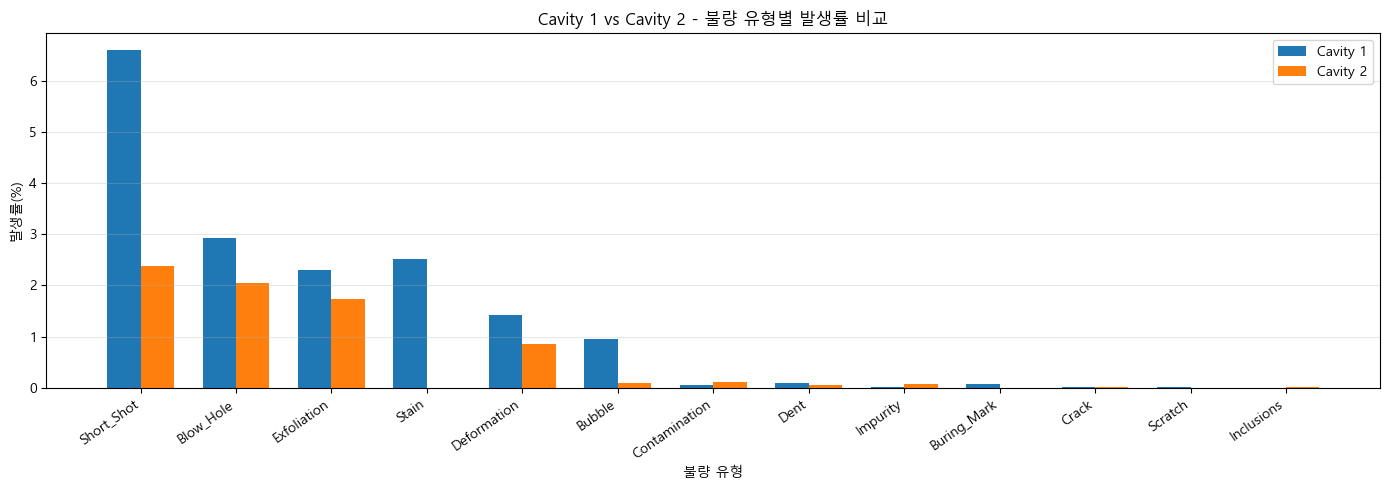

In [88]:
x = np.arange(len(order))
w = 0.35

plt.figure(figsize=(14, 5))
plt.bar(x - w/2, rate1.values, width=w, label="Cavity 1")
plt.bar(x + w/2, rate2.values, width=w, label="Cavity 2")

plt.title("Cavity 1 vs Cavity 2 - 불량 유형별 발생률 비교")
plt.xlabel("불량 유형")
plt.ylabel("발생률(%)")
plt.xticks(x, order, rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

1. Short_Shot: 미성형(충전 부족) 불량 — 용탕이 금형 끝까지 다 채워지지 않아 모서리/얇은 부위가 덜 찍히거나 일부가 비는 현상.
2. Bubble: 기포 불량 — 주조 중 갇힌 가스/공기가 내부나 표면에 기포로 남아 강도 저하·누설/외관 불량을 유발.
3. Exfoliation: 박리(층 분리/벗겨짐) 불량 — 표면층이 뜨거나 층이 분리되어 벗겨지는 형태로, 표면 품질·내구성을 크게 떨어뜨림.
4. Blow_Hole: 블로홀/기공 불량 — 응고 중 가스/수축으로 생긴 비교적 큰 공극(구멍)으로, 단면 기공·핀홀처럼 나타남.
5. Stain: 얼룩 불량 — 산화막/윤활제/오염 영향으로 표면 색이 불균일하게 남아 얼룩처럼 보이는 외관 불량.
6. Dent: 찍힘/눌림 불량 — 취출·이송·적재 과정에서 충격/압력으로 표면이 눌리거나 자국이 생긴 외관/치수 불량.
7. Scratch: 스크래치 불량 — 금형, 이송 설비, 공구, 적재 간 마찰로 표면에 선형 흠집이 생기는 외관 불량.
8. Buring_Mark: 번마크/그을림 불량 — 고온 가스/산화 영향으로 표면이 그을리거나 변색되는 현상(검게 타거나 갈변).
9. Deformation: 변형 불량 — 응고 후 취출·냉각·후공정 중 응력/열로 휘어짐·뒤틀림이 생겨 형상/치수가 틀어짐.
10. Crack: 균열 불량 — 응고수축·열응력·과도한 취출력 등으로 미세~육안 균열이 발생해 파손 위험이 커짐.
11. Contamination: 오염(이물) 불량 — 분진/오일/칩 등 외부 이물이 표면에 붙거나 끼어 도장·외관·조립성 문제를 만듦.
12. Impurity: 불순물 불량 — 용탕 내 불순 성분/산화물 등이 섞여 품질이 저하되고 표면 결함·취성 증가로 이어짐.
13. Inclusions: 개재물(내부 이물) 불량 — 산화막/슬래그 등 비금속물이 내부에 갇혀 단면에 점/덩어리로 보이며 강도를 약화.

1. Short_Shot: 미성형(충전 부족) 불량 — 용탕이 금형 끝까지 다 채워지지 않아 모서리/얇은 부위가 덜 찍히거나 일부가 비는 현상.
2. Blow_Hole: 블로홀/기공 불량 — 응고 중 가스/수축으로 생긴 비교적 큰 공극(구멍)으로, 단면 기공·핀홀처럼 나타남.
3. Exfoliation: 박리(층 분리/벗겨짐) 불량 — 표면층이 뜨거나 층이 분리되어 벗겨지는 형태로, 표면 품질·내구성을 크게 떨어뜨림.
4. Stain: 얼룩 불량 — 산화막/윤활제/오염 영향으로 표면 색이 불균일하게 남아 얼룩처럼 보이는 외관 불량.
5. Deformation: 변형 불량 — 응고 후 취출·냉각·후공정 중 응력/열로 휘어짐·뒤틀림이 생겨 형상/치수가 틀어짐.
6. Bubble: 기포 불량 — 주조 중 갇힌 가스/공기가 내부나 표면에 기포로 남아 강도 저하·누설/외관 불량을 유발.

Short_Shot, Blow_Hole, Exfoliation, Stain, Deformation

불량 판정(불량/양품)은 26개 중 하나라도 발생하면 불량으로 판정.\
대신 불량 유형은 분량 빈도? 중요도 기준으로 잡고, 나머지는 기타(Etc)로 묶어 클래스 수를 줄인다.

1. 빈도 기반으로 나누기 (값의 대표성)
2. 중요도 기반으로 나누기 (도메인)

Short_Shot (미성형/충전 부족)

Blow_Hole / Bubble (기공/가스 계열)

Exfoliation

Deformation

Stain

In [127]:
# 주요 불량, 나머진 기타로 잡음
major = ["Short_Shot", "Blow_Hole", "Exfoliation", "Stain", "Deformation"]

# 1) 표 만들기: 주요 5개는 그대로, 나머지는 Etc로 합치기
summary_major = summary.loc[major].copy()

etc_row = summary.drop(index=major).sum()   # Cavity1/2/합 컬럼 합쳐짐
summary_group = pd.concat([summary_major, pd.DataFrame([etc_row], index=["Etc"])])

# 보기 좋게(선택)
summary_group = summary_group[["Cavity1(%)", "Cavity2(%)", "Cavity_sum"]].round(6)

summary_group

,Cavity1(%),Cavity2(%),Cavity_sum
Short_Shot,6.595886,2.388852,8.984738
Blow_Hole,2.932979,2.057067,4.990046
Exfoliation,2.295952,1.738553,4.034506
Stain,2.508295,0.000000,2.508295
Deformation,1.433311,0.849370,2.282681
Etc,1.234240,0.358328,1.592568


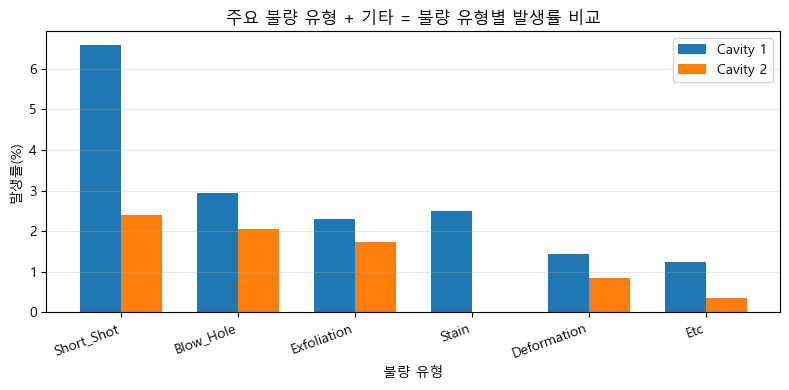

In [128]:
# 2) Major/Etc로 묶은 요약 표 (캐비티별도 같이)
labels = summary_group.index.tolist()
x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - w/2, summary_group["Cavity1(%)"].values, width=w, label="Cavity 1")
plt.bar(x + w/2, summary_group["Cavity2(%)"].values, width=w, label="Cavity 2")

plt.title("주요 불량 유형 + 기타 = 불량 유형별 발생률 비교")
plt.xlabel("불량 유형")
plt.ylabel("발생률(%)")
plt.xticks(x, labels, rotation=20, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 결측치 처리

In [92]:
# =========================
# 결측치(NA) 구조 확인 (+ 컬럼별 비율)
# =========================
print("===== 결측치(NA) 확인 =====")

n_rows = len(df)

na_count = df.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0]

# 그룹별 결측치 개수(총 결측 수) - 기존 그대로
print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": process_df.isna().sum().sum(),
    "Sensor":  sensor_df.isna().sum().sum(),
    "Defects": defects_df.isna().sum().sum()
}))
print()

# 컬럼별 결측치 개수
print("결측치가 있는 컬럼만(개수):")
print(na_cols)
print()

# 컬럼별 결측치 비율(%): (결측 행 수 / 전체 행 수) * 100
print("결측치가 있는 컬럼만(비율 %):")
print(((na_cols / n_rows) * 100).round(4))
print()

===== 결측치(NA) 확인 =====
그룹별 결측치 합(총 결측 수):
Process      0
Sensor     540
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
Sensor  Factory_Temp            90
        Factory_Humidity        90
        Factory_Temp_Max        90
        Factory_Humidity_Max    90
        Factory_Humidity_Min    90
        Factory_Temp_Min        90
dtype: int64

결측치가 있는 컬럼만(비율 %):
Sensor  Factory_Temp            1.1944
        Factory_Humidity        1.1944
        Factory_Temp_Max        1.1944
        Factory_Humidity_Max    1.1944
        Factory_Humidity_Min    1.1944
        Factory_Temp_Min        1.1944
dtype: float64



Factory_Temp: 공장(주변 환경) 온도\
Factory_Humidity: 공장(주변 환경) 습도\
Factory_Temp_Max: 공장 온도 최대값\
Factory_Temp_Min: 공장 온도 최소값\
Factory_Humidity_Max: 공장 습도 최대값\
Factory_Humidity_Min: 공장 습도 최소값


선택지 1. 삭제하기\
특정 센서(공장 환경)만 빠진 케이스라 분석을 크게 해치지 않을 가능성이 존재

선택지 2. 결측을 대체 혹은 플래그 추가\
median이 제일 무난

## 이상치 처리

In [93]:
col_uniques = defects_df.apply(lambda s: sorted(s.dropna().unique()))
col_uniques

Short_Shot_1       [0, 1]
Bubble_1           [0, 1]
Exfoliation_1      [0, 1]
Blow_Hole_1        [0, 1]
Stain_1            [0, 1]
Dent_1             [0, 1]
Deformation_1      [0, 1]
Contamination_1    [0, 1]
Impurity_1         [0, 1]
Crack_1            [0, 1]
Scratch_1          [0, 1]
Buring_Mark_1      [0, 1]
Inclusions_1          [0]
Short_Shot_2       [0, 1]
Bubble_2           [0, 1]
Exfoliation_2      [0, 1]
Blow_Hole_2        [0, 1]
Stain_2               [0]
Dent_2             [0, 1]
Deformation_2      [0, 1]
Contamination_2    [0, 1]
Impurity_2         [0, 1]
Crack_2            [0, 1]
Scratch_2             [0]
Buring_Mark_2         [0]
Inclusions_2       [0, 1]
dtype: object

In [94]:
# 관심 값(필요하면 더 추가)
vals = [0, 1, 2, 3]

exist = pd.DataFrame(index=defects_df.columns)
for v in vals:
    exist[f"has_{v}"] = (defects_df == v).any()

exist["has_NaN"] = defects_df.isna().any()

# 값이 2 이상 있는 컬럼만 보고 싶으면
exist[exist["has_2"] | exist.get("has_3", False)].sort_index()

,has_0,has_1,has_2,has_3,has_NaN


In [95]:
def analyze_each_column_distribution(df, df_name):
    
    print(f"{'='*80}")
    print(f"{df_name}의 컬럼별 값 분포")
    print(f"{'='*80}")
    
    for col in df.columns:
        print(f"\n[{col}]")
        
        # 고유값 및 정렬
        unique_values = sorted(df[col].unique())
        
        # 고유값별 개수와 비율
        # .value_counts(): 각 고유값의 개수 계산 (빈도수 많은 순)
        # .sort_index(): 고유값 순서대로 재정렬 (오름차순)
        value_counts = df[col].value_counts().sort_index()
        
        # 분포 테이블 생성
        dist_list = []
        for val in unique_values:
            count = value_counts.get(val, 0)
            pct = round(count / len(df) * 100, 2)
            dist_list.append({
                '고유값': val,
                '개수': count,
                '비율(%)': pct
            })
        
        dist_df = pd.DataFrame(dist_list)
        display(dist_df)

In [96]:
# 함수 실행
analyze_each_column_distribution(defects_df, 'Defects')

Defects의 컬럼별 값 분포

[Short_Shot_1]


,고유값,개수,비율(%)
0,0,7038,93.4
1,1,497,6.6



[Bubble_1]


,고유값,개수,비율(%)
0,0,7463,99.04
1,1,72,0.96



[Exfoliation_1]


...

,고유값,개수,비율(%)
0,0,7535,100.0



[Buring_Mark_2]


,고유값,개수,비율(%)
0,0,7535,100.0



[Inclusions_2]


,고유값,개수,비율(%)
0,0,7534,99.99
1,1,1,0.01


### 이상치 IQR

In [ ]:
import matplotlib.pyplot as plt

# 1) X, y 준비
X = pd.concat([process_df, sensor_df], axis=1).drop(columns=["id"])
y = y_any_defect

# 2) 결측치 처리: 중앙값으로 채우기(간단하게)->머신러닝 할땐 안쓸꺼임
X = X.fillna(X.median(numeric_only=True))

print("\n===== 전처리 결과 =====")
print("X shape:", X.shape)
print("y 분포:")
print(y.value_counts())
print("남은 결측치:", X.isna().sum().sum())
print()

In [ ]:
# 3) IQR 기반 이상치 마스크
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr # lower 보다 작으면 이상치
upper = q3 + 1.5 * iqr # upper 보다 크면 이상치

# 이상치 마스크 만들기(True/False 표)
outlier_mask = X.lt(lower) | X.gt(upper) # True: 이상치, False: 정상
# X가 lower보다 작은지(less than) → True/False
# X가 upper보다 큰지(greater than) → True/False
# 둘 중 하나라도 True면 이상치(True)

# IQR=0인 컬럼은 이상치 판단이 의미 없을 수 있으니 제외
zero_iqr_cols = iqr.eq(0)
outlier_mask.loc[:, zero_iqr_cols] = False

# 4) 컬럼별 이상치 개수/비율
outlier_count_by_col = (
    outlier_mask
    .sum() # 이상치 총합
    .sort_values(ascending=False) # 이상치가 많은 컬럼부터 정렬
)
outlier_ratio_by_col = (outlier_count_by_col / len(X)).sort_values(ascending=False) # 비율화

print("===== 이상치 TOP 15: 개수 =====")
print(outlier_count_by_col.head(15))
print()

print("===== 이상치 TOP 15: 비율 =====")
print(outlier_ratio_by_col.head(15))
print()

rows_with_any_outlier = outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any_outlier, "/", len(X))
print("비율:", rows_with_any_outlier / len(X))
print()

In [ ]:
# 4) 시각화: 이상치 많은 컬럼 상위 6개 박스플롯
top_cols = outlier_count_by_col[outlier_count_by_col > 0].head(5).index

plt.figure(figsize=(12, 4))
X[top_cols].plot(kind="box")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print("===== TOP 컬럼 min/max =====")
print(X[top_cols].agg(["min", "max"]))
print()

tmp = X[top_cols].copy()
tmp["y"] = y

print("===== 불량/양품 평균(mean) 비교 =====")
print(tmp.groupby("y")[top_cols].mean())
print()

print("===== 불량/양품 중앙값(median) 비교 =====")
print(tmp.groupby("y")[top_cols].median())
print()

### 이상치 IQR 보고
이상치 기준: IQR\
하한 = Q1 - 1.5×IQR\
상한 = Q3 + 1.5×IQR\
하한보다 작거나 상한보다 크면 이상치로 판단

1. 이상치가 1개라도 존재하는 행\
590 / 7,535 (약 7.83%)

2. 이상치가 많은 컬럼 TOP (개수 기준)
    1. Factory_Temp : 374개 (약 4.96%)
    2. Velocity_2 : 184개 (약 2.44%)
    3. Biscuit_Thickness : 12개
    4. Cycle_Time : 11개
    5. High_Velocity : 10개
    6. Rapid_Rise_Time : 10개
    7. 그 외 Velocity_1, Pressure_Rise_Time, Velocity_3, Cylinder_Pressure 등은 소수
    - 이상치는 Factory_Temp, Velocity_2에 상대적으로 많이 집중되어 있다.

3. 이상치 값 범위
    1. Factory_Temp: 27.4 ~ 37.0
    2. Velocity_2: 0.158 ~ 0.212
    3. Biscuit_Thickness: 0 ~ 24
    4. Cycle_Time: 20.2 ~ 218.6
    5. High_Velocity: 0.0 ~ 2.744
    - 0인 값들이 존재하기 때문에 측정 오류인지, 특정 상황인지 추후에 판단

4. 불량/양품 간 차이(참고: 평균·중앙값)
    - Cycle_Time, Biscuit_Thickness, High_Velocity는 불량(1)에서 더 큰 경향이 관찰된다
        - Biscuit_Thickness: 양품 13.0 → 불량 16.0
        - Cycle_Time: 양품 22.5 → 불량 35.0
        - High_Velocity: 양품 2.157 → 불량 2.506
    - 단순 이상치 보단 불량 신호일 가능성으로 볼수 있음

5. 판단
- IQR 기준 이상치는 행 기준 약 7.8% 수준, 특정 변수에 집중되어 있다.
- 현재 단계에서는 이상치가 불량 신호일 가능성도 존재한다.
- 제거/클리핑 처리는 추후 회의를 통해 결정

### 이상치 z-score

### 이상치 z-score 보고